In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("boston.csv")
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [5]:
X = df.drop("MEDV", axis=1).values
y = df["MEDV"].values

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
model = Sequential()

In [9]:
model.add(Dense(64,activation='relu',input_shape=(13,)))
model.add(Dense(32,activation='relu'))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [11]:
history = model.fit(X_train,y_train,epochs=100,batch_size=16,validation_split=0.2,verbose=1)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 601.9015 - mae: 22.6084 - val_loss: 509.8440 - val_mae: 20.9806
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 529.4164 - mae: 20.9266 - val_loss: 437.2125 - val_mae: 19.1605
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 433.0583 - mae: 18.5439 - val_loss: 335.7503 - val_mae: 16.3731
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 308.3518 - mae: 15.0838 - val_loss: 206.3932 - val_mae: 12.3812
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 172.4443 - mae: 10.5565 - val_loss: 103.4973 - val_mae: 7.8908
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 95.9640 - mae: 7.7637 - val_loss: 60.0275 - val_mae: 5.5378
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 65.0078 - mae: 6.2787 - val_loss: 42.5770 - val_mae: 4.5642
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 46.1998 - mae: 5.1687 - val_loss: 34.6144 - val_mae: 4.0767
Epoch 9/100
21/21 ━━━━━━

In [13]:
loss, mae = model.evaluate(X_test,y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 11.0434 - mae: 2.2843


In [14]:
predictions = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [15]:
for i in range(10):
  print("Actual price: ",y_test[i])
  print("Predicted price: ",predictions[i][0])


Actual price:  23.6
Predicted price:  28.160788
Actual price:  32.4
Predicted price:  33.909985
Actual price:  13.6
Predicted price:  17.61152
Actual price:  22.8
Predicted price:  26.249367
Actual price:  16.1
Predicted price:  15.951182
Actual price:  20.0
Predicted price:  20.676722
Actual price:  17.8
Predicted price:  16.5774
Actual price:  14.0
Predicted price:  13.966176
Actual price:  19.6
Predicted price:  26.205544
Actual price:  16.8
Predicted price:  17.87631


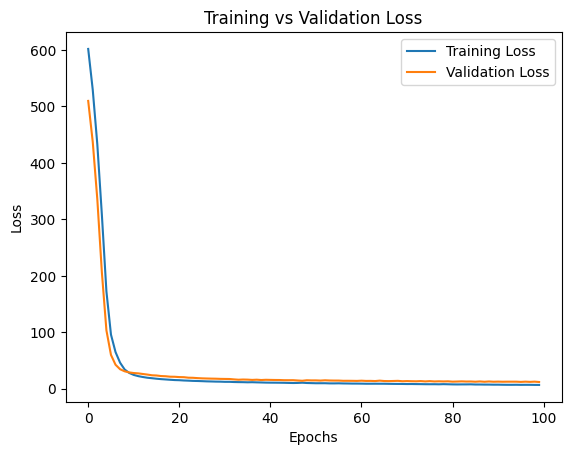

In [16]:
plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()